# 03 - Plume Lagrangian Evolution
Derived from `notebooks/prior_versions/plume_path_plot_clean.ipynb`.\n

In [24]:
import platform
import socket
import sys
from pathlib import Path

src_dir = next(p / "src" for p in (Path.cwd(), *Path.cwd().parents) if (p / "src" / "polarcap_runtime.py").is_file())
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from polarcap_runtime import is_server

print("system:", platform.system(), platform.release())
print("hostname:", socket.gethostname())
print("is_server:", is_server())

system: Darwin 25.3.0
hostname: MacBookPro
is_server: False


In [ ]:
from __future__ import annotations

import sys
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from utilities import _assign_elapsed_time, _prepare_da
from matplotlib.lines import Line2D


xr.set_options(keep_attrs=True)
_src = next((p / "src" for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utilities").is_dir()), (Path.cwd() / ".." / ".." / "src").resolve())
sys.path.insert(0, str(_src))

from utilities import (
    make_pastel,
    create_fade_cmap,
    load_plume_path_runs,
    plot_plume_path_sum,
    build_common_xlim,
    diagnostics_table,
    prepare_holimo_for_overlay,
)
from utilities.plotting import create_new_jet3

# Colormaps for plume-path (ice + transition + BkBl; soft for overlay)
new_jet4 = create_new_jet3(1024)
new_jet3 = create_new_jet3()
CMAP = create_fade_cmap(make_pastel(new_jet3, desaturation=0.25, darken=0.90), n_fade=2)


In [26]:
# ---- user config ----\n
PROCESSED_ROOT = Path("../data/processed")
RUNS = [
    # {"label": "400m, inp 1e6, ccn 0 (run A)", "cs_run": "cs-eriswil__20251129_230943", "exp_id": "20251129231107"},
    # {"label": "400m, inp 1e6, ccn 0 (run B)", "cs_run": "cs-eriswil__20251129_230943", "exp_id": "20260119103733"},
    # {"label": "400m, inp 1e6, ccn 400 (columnar)", "cs_run": "cs-eriswil__20251125_114053", "exp_id": "20260120122711"},
    {"label": "400m, inp 1e6, ccn 0 (spherical)", "cs_run": "cs-eriswil__20251125_114053", "exp_id": "20251125114238"},
    # {"label": "400m, inp 1e6, ccn 400 (analytic)", "cs_run": "cs-eriswil__20260127_211338", "exp_id": "20260127211431"},
    # {"label": "400m, inp 1e6, ccn 400 (planar)", "cs_run": "cs-eriswil__20260127_211338", "exp_id": "20260127211551"},
    # {"label": "400m, inp 1e6, ccn 400 (spherical)", "cs_run": "cs-eriswil__20260121_131528", "exp_id": "20260121131550"},
    {"label": "400m, inp 1e6, ccn 400 (columnar 2)", "cs_run": "cs-eriswil__20260121_131528", "exp_id": "20260121131632"},
    # {"label": "100m, inp 1e6, ccn 0 (columnar)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181336"},
    # {"label": "100m, inp 1e6, ccn 400 (columnar)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181750"},
    # {"label": "100m, inp 1e6, ccn 400 (spherical, same exp)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181750"},
]

KINDS = ("integrated","vertical","extreme")

datasets = load_plume_path_runs(
    RUNS,
    processed_root=PROCESSED_ROOT,
    kinds=KINDS,
)

try:
    xlim = build_common_xlim(datasets, kind="integrated", span_min=35)
except ValueError:
    # Fallback window if no valid times are discoverable in current environment.
    xlim = [np.datetime64("2023-01-25T12:29:00"), np.datetime64("2023-01-25T13:04:00")]
    # xlim = [np.datetime64("2023-01-25T12:29:00"), np.datetime64("2023-01-25T13:04:00")]

diag = diagnostics_table(datasets, kind="integrated", variable="nf", xlim=xlim)
print(diag.to_string(index=False))


                                run status  n_cells  n_time            time_min            time_max  has_var  n_time_in_xlim  finite_in_xlim
   400m, inp 1e6, ccn 0 (spherical)     ok        3     248 2023-01-25T12:23:20 2023-01-25T13:04:30     True             211            6267
400m, inp 1e6, ccn 400 (columnar 2)     ok        5     289 2023-01-25T12:23:50 2023-01-25T13:11:50     True             211           12066


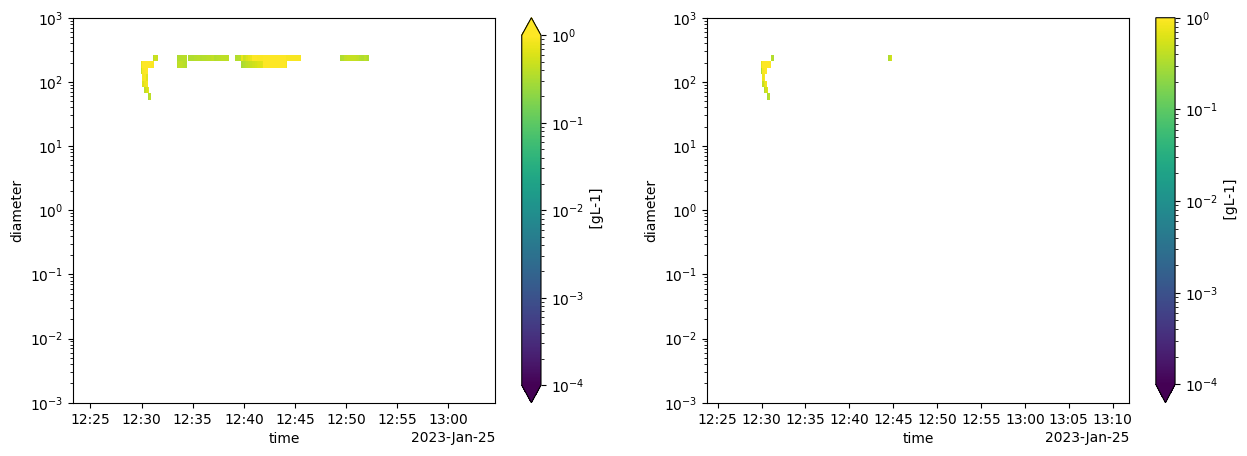

In [27]:
from matplotlib.colors import LogNorm as _LogNorm
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))
for i in range(2):
    da_ = datasets[RUNS[i]['label']]['extreme']
    # only liquid shell
    da_wshell = 1 - (da_['qf']/da_['qfw'])
    da_wshell = xr.where(da_wshell > 0.3, da_wshell, 0)
    da_wshell.sum(dim=['cell']).plot(ax=ax[i], x='time', yscale='log', ylim=(1e-3, 1000), norm=_LogNorm(vmin=1e-4, vmax=1))




# 03 - Plume Lagrangian Evolution


TBD: check how much smoothing of the Holimo data is needed to do a comparison with the model data. Holimos observationsal volume is in order of a couple of centimeters compared to the model which is of horizontal resolution of >400m (or >100m depending on the run).


In [28]:
holimo_file = "../data/observations/holimo_data/CL_20230125_1000_1140_SM058_SM060_ts1.nc"
time_window_holimo = (np.datetime64("2023-01-25T10:10:00"), np.datetime64("2023-01-25T12:00:00"))
time_frames_plume = [
    [np.datetime64("2023-01-25T10:56:00"), np.datetime64("2023-01-25T11:04:00")],
    [np.datetime64("2023-01-25T10:35:00"), np.datetime64("2023-01-25T10:42:00")],
    [np.datetime64("2023-01-25T11:24:00"), np.datetime64("2023-01-25T11:29:00")],
]
obs_ids = ["SM059", "SM058", "SM060"]
growth_times_min = [6.1, 8.0, 9.1] # omanovic2024a
# growth_times_min = [6.7, 8.1, 8.7] # miller2025
seeding_start_times = [
    np.datetime64("2023-01-25T10:50:00"),
    np.datetime64("2023-01-25T10:28:00"),
    np.datetime64("2023-01-25T11:15:00"),
]

if 'ds_hd10' not in globals() or True:
    ds_hd10 = prepare_holimo_for_overlay(
        holimo_file,
        time_window_holimo,
        resample_s=10,
        smoothing_time_bins=3,
        min_coverage_frac=0.01,
    )




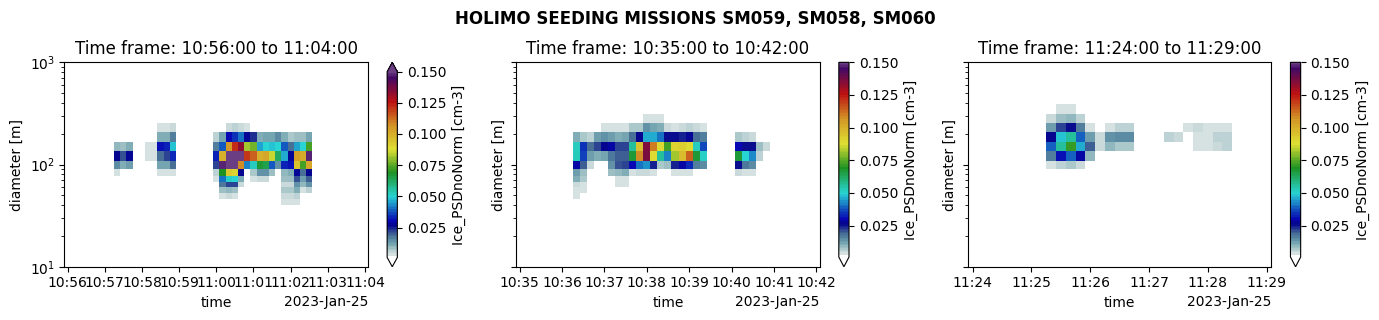

In [29]:
if 'ds_hd10' in globals():
    da_ = ds_hd10["Ice_PSDnoNorm"]
    fig, ax = plt.subplots(ncols=len(time_frames_plume), figsize=(14, 3), sharey=True)
    for i, (t0,t1) in enumerate(time_frames_plume):
        da_.sel(time=slice(t0, t1)).plot(ax=ax[i], x='time', yscale='log', ylim=(1e1, 1e3), cmap=new_jet3_soft, vmin=0.001, vmax=0.15)
        ax[i].set_title(f"Time frame: {str(t0)[-8:]} to {str(t1)[-8:]}")
    
    plt.tight_layout()
    plt.suptitle(f"HOLIMO SEEDING MISSIONS {', '.join(obs_ids)}", y=1.05, weight="bold")
    plt.show()

### HOLIMO time smoothing (gap-aware, paper method)

We process HOLIMO time series with a gap-aware workflow before plume comparisons:

- **Regularization:** resample to a fixed `10 s` grid (`mean`).
- **Coverage filter:** keep only `10 s` bins with at least `20%` of expected raw samples (for `0.2 s` raw data, threshold = `10` samples per `10 s` bin).
- **Smoothing:** apply a centered `30 s` rectangular window (`rolling(time=3, center=True, min_periods=2)`) on the regularized series.

This keeps the effective smoothing window consistent in time and limits bias from irregular sampling gaps.

In [30]:
# --- Ensemble Mean FoO ---
import pandas as pd
import numpy as np
import xarray as xr

ensemble_datasets = {"Ensemble Mean": {}}
all_kinds = set(k for run in datasets.values() for k in run.keys())


for kind in all_kinds:
    time_grids = []
    for lbl, run in datasets.items():
        if isinstance(run.get(kind), xr.Dataset) and "nf" in run[kind]:
            time_grids.append(run[kind]["nf"].time.values)
            diameter_bin_edges = run[kind].diameter_edges.values

    if time_grids:
        t_min = min(t.min() for t in time_grids)
        t_max = max(t.max() for t in time_grids)
        common_time = pd.date_range(start=t_min, end=t_max, freq="10s")
        
        da_list = []
        for lbl, run in datasets.items():
            if isinstance(run.get(kind), xr.Dataset) and "nf" in run[kind]:
                da = run[kind]["nf"]
                if "cell" in da.dims:
                    da = da.sum("cell", keep_attrs=True, skipna=True)
                if kind == "vertical" and "altitude" in da.dims:
                    da = da.mean("altitude", keep_attrs=True, skipna=True)
                da_interp = da.reindex(time=common_time, method="nearest", tolerance="5s", fill_value=0.0)
                da_list.append(da_interp)
                
        if da_list:
            da_mean = xr.concat(da_list, dim="run").mean(dim="run", keep_attrs=True)
            ds_mean = xr.Dataset({"nf": da_mean})
            first_run = next(r for r in datasets.values() if isinstance(r.get(kind), xr.Dataset))[kind]
            ds_mean.attrs.update(first_run.attrs)
            ds_mean["nf"].attrs = da_list[0].attrs
            model_bin_width = xr.ufuncs.log(diameter_bin_edges[1:]) - xr.ufuncs.log(diameter_bin_edges[:-1])
            ds_mean["nf"]   = ds_mean["nf"] / model_bin_width
            ensemble_datasets["Ensemble Mean"][kind] = ds_mean

#
#
#
if not ensemble_datasets["Ensemble Mean"]:
    ensemble_datasets = datasets  # Fallback

# Plot configuration starts here

In [31]:
# Plot configuration starts here
from matplotlib.colors import LogNorm as _LogNorm

# Updated FoO block: one model line over global HOLIMO elapsed window.
# holimo_ice_var = 
# holimo_overlay_cfg = {
#     "ds_hd10": ds_hd10,
#     "obs_ids": obs_ids,
#     "time_frames_plume": time_frames_plume,
#     "growth_times_min": growth_times_min,
#     "seeding_start_times": seeding_start_times,
#     "var": holimo_ice_var,
#     "threshold": 1e-10,
#     "unit_factor": 1e3,
#     "scatter_cmap": new_jet3_soft,
#     "markers": ["o", "s", "^"],
#     "sizes": [90, 90, 90],
#     "alpha": 1.0,
#     "edgecolor": "black",
#     "linewidth": 0.25,
#     "legend_loc": "lower right",
#     "marker_size_scale": 1.0,
# }

kind = 'extreme'
# Histogram settings for comparison panel.
xlim_npdatetime = [np.datetime64("2023-01-25T12:29:00"), np.datetime64("2023-01-25T13:14:00")]
xlims = {"symlog": [0, 45],   "elapsed": [4, 16]}
ylims = {"symlog": [5, 1000], "elapsed": [20, 250]}
zlims = {"symlog": [1, 1000], "elapsed": [1, 1000]}
zoom_window_config = [("symlog",  xlims["symlog"],  ylims["symlog"],  zlims["symlog"]), 
                      ("elapsed", xlims["elapsed"], ylims["elapsed"], zlims["elapsed"]),
                      ("hist",    (20.0, 280.0),    (0.1, 100.0),     (None, None))]
absolute_mode = True  # True: absolute time-mean concentration, False: FoO (%)


# ==== HOLIMO vertical scatter at growth-time positions ====
da_obs   = ds_hd10["Ice_PSDnoNorm"]
ufactor  = 1e3
thr      = 1e-10
markers  = [90, 90, 90]
sc_cmap  = new_jet3_soft
sc_norm  = _LogNorm(vmin=zlims["elapsed"][0], vmax=zlims["elapsed"][1])



### Plot Functions ###

#### holimo scatter points vertikal plotten bei x=residence time
#### kind=extreme anstatt integrated 
#### hoeheren threshold fuer tobac tracking

In [53]:
from matplotlib.colors import LogNorm
from utilities import _assign_elapsed_time, _prepare_da

# ======================== CONFIG ========================
HOLIMO_VAR   = "Ice_PSDlogNorm"
UNIT_CONVERSION  = 1000          # HOLIMO cm-3 -> L⁻¹
THRESHOLD    = 1e-10             # 1 ice crystal per bin
MODEL_SEED   = np.datetime64("2023-01-25T12:30:00")
KIND         = "extreme"
XLIM         = [np.datetime64("2023-01-25T12:29:00"), np.datetime64("2023-01-25T13:14:00")]
CMAP         = create_fade_cmap(make_pastel(new_jet3, desaturation=0.25, darken=0.90), n_fade=2)
SCALE_STYLE  = ["symlog", "elapsed"]

# Panel axis limits: {panel_key: (x_range, y_range, z_range)}
PANEL_LIMS = {
    "symlog":  ([0, 45],       [5, 1000],  [1, 2000]),
    "elapsed": ([4, 12],       [20, 200],  [1, 2000]),
    "hist":    ((20.0, 500.0), (1, 1000.0), None),
}

# Shared scatter kwargs for HOLIMO vertical columns
MISSION_MARKERS = ["o", "s", "^"]
SCATTER_KW = dict(s=70, edgecolors="black", linewidths=0.35, alpha=0.95, zorder=130,
                  cmap=CMAP, norm=LogNorm(vmin=PANEL_LIMS["symlog"][2][0], vmax=PANEL_LIMS["symlog"][2][1]))

# Shared kwargs for plot_plume_path_sum calls
PMESH_KW = dict(kind=KIND, variable="nf", common_xlim_minutes=35, xlim=XLIM,
                cmap=CMAP, log_norm=True, add_missing_data=True,
                holimo_overlay=None, add_colorbar=False, add_shared_labels=False,
                annote_letters=False, return_pmesh=True, add_holimo_legend=False)
CBAR_KW = dict(shrink=0.8, aspect=25, pad=0.0, extend="both")

# Marker kwargs for histogram annotations
PEAK_MK  = dict(marker=">", s=80, ec="black", lw=0.6, zorder=100, clip_on=True)
MED_MK   = dict(marker="v", s=70, ec="black", lw=0.9, zorder=100, clip_on=True)

float_fmt = plt.FuncFormatter(lambda x, _: f'{x:.3f}'.rstrip('0').rstrip('.') if x < 1 else f'{x:.0f}')



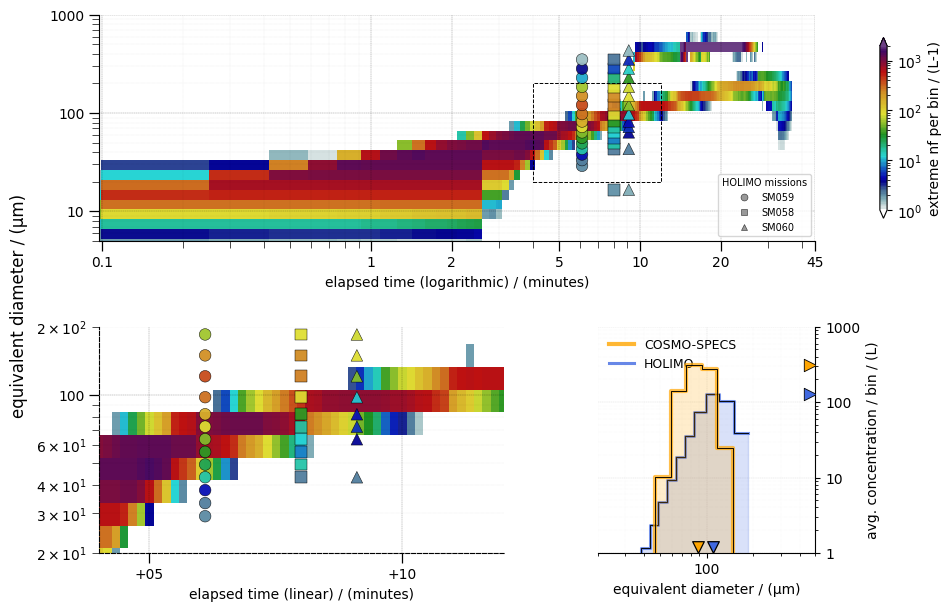

In [54]:
# ======================== HELPERS ========================
def _diam_log_edges(centers):
    """Log-spaced bin edges from diameter centers."""
    c = np.unique(np.sort(centers[np.isfinite(centers) & (centers > 0)]))
    lc = np.log(c)
    e = np.empty(c.size + 1)
    e[1:-1] = 0.5 * (lc[:-1] + lc[1:])
    e[0]  = lc[0]  - 0.5 * (lc[1]  - lc[0])
    e[-1] = lc[-1] + 0.5 * (lc[-1] - lc[-2])
    return np.exp(e)

def _hist_profile(da, threshold=0.0, bin_edges=None):
    """Time-integrated concentration profile binned by diameter."""
    extra = [d for d in da.dims if d not in ("time", "diameter")]
    if extra:
        da = da.mean(dim=extra, skipna=True)
    diam = np.asarray(da["diameter"].values, dtype=float)
    tvals, vals = np.asarray(da["time"].values), np.asarray(da.values, dtype=float)
    if bin_edges is None:
        bin_edges = _diam_log_edges(diam)
    vals = np.where(np.isfinite(vals) & (vals > threshold), vals, 0.0)
    t_min = ((tvals - tvals[0]) / np.timedelta64(1, "m")).astype(float)
    hist, _ = np.histogram(diam, bins=bin_edges, weights=np.trapezoid(vals, x=t_min, axis=0))
    return np.sqrt(bin_edges[:-1] * bin_edges[1:]), hist.astype(float)

def _elapsed_dur(da):
    """Duration of time dim in minutes."""
    t = np.asarray(da["time"].values)
    return max(float((t[-1] - t[0]) / np.timedelta64(1, "m")), 0.0) if t.size >= 2 else 0.0

def _plot_hist_line(ax, d, f, color, lw, label=None, z=10):
    """Filled step + colored step + thin black outline."""
    ax.fill_between(d, f, step="pre", color=color, alpha=0.2, zorder=z)
    ax.step(d, f, color=color, lw=lw, alpha=0.7, zorder=z+1, label=label)
    ax.step(d, f, color="black", lw=0.7, alpha=0.95, zorder=z+2)

def _peak_indices(f, n=2):
    """Indices of up to n local maxima, descending by value."""
    f = np.asarray(f, dtype=float)
    if f.size < 3:
        return (int(np.nanargmax(f)),) if f.size and np.isfinite(f).any() else ()
    idx = [i for i in range(1, f.size-1) if np.isfinite(f[i]) and f[i] >= f[i-1] and f[i] >= f[i+1]]
    return tuple(sorted(idx or [int(np.nanargmax(f))], key=lambda i: f[i], reverse=True)[:n])

def _median_diam(d, f):
    """Weighted-median diameter from a single-mode profile."""
    cdf = np.nancumsum(f)
    return float(np.interp(0.5, cdf / cdf[-1], d)) if cdf[-1] > 0 else np.nan


# ======================== FIGURE LAYOUT ========================
fig, gs = plt.figure(figsize=(9.4, 6.0), constrained_layout=True), None
gs = fig.add_gridspec(2, 2, width_ratios=[0.65, 0.35], wspace=0.1, hspace=0.1)
ax_symlog  = fig.add_subplot(gs[0, 0:2])
ax_elapsed = fig.add_subplot(gs[1, 0])
ax_hist    = fig.add_subplot(gs[1, 1])


# ======================== 1. PCOLORMESH PANELS ========================
pmesh_ref = None
for ax_pm, (fmt, panel_key) in [(ax_symlog, (SCALE_STYLE[0], SCALE_STYLE[0])), 
                                (ax_elapsed, (SCALE_STYLE[1], SCALE_STYLE[1]))]:
    xr_, yr_, zr_ = PANEL_LIMS[panel_key]
    _, _, pmesh = plot_plume_path_sum(
        ensemble_datasets, x_axis_fmt=fmt, zlim=zr_,
        axes_override=[ax_pm], cbar_kwargs=CBAR_KW, **PMESH_KW)
    ax_pm.set_xlim(xr_); ax_pm.set_ylim(yr_)
    if pmesh_ref is None:
        pmesh_ref = pmesh

# Zoom rectangle on symlog panel
xz, yz = PANEL_LIMS["elapsed"][:2]
ax_symlog.add_patch(plt.Rectangle((xz[0], yz[0]), xz[1]-xz[0], yz[1]-yz[0],
                                  fill=False, ec="black", ls="--", lw=0.7, zorder=300))
ax_elapsed.set_title("")
ax_symlog.set_xticks([t for t in ax_symlog.get_xticks() if not np.isclose(t, 0.0)])

# Spine styling
for sp in ax_elapsed.spines.values():
    sp.set_color("black"); sp.set_linestyle("--")
for a in (ax_symlog, ax_elapsed):
    a.spines["top"].set_visible(False); a.spines["right"].set_visible(False)
ax_hist.spines["top"].set_visible(False); ax_hist.spines["left"].set_visible(False)

# Colorbar
unit = ensemble_datasets[next(iter(ensemble_datasets))][KIND]["nf"].attrs.get("units", "-")
fig.colorbar(pmesh_ref, ax=ax_symlog, **CBAR_KW).set_label(rf"{KIND} nf per bin / ({unit})")


# ======================== 2. HOLIMO SCATTER AT GROWTH TIMES ========================
da_holimo = ds_hd10[HOLIMO_VAR] * UNIT_CONVERSION
mission_profiles = []
for im, (oid, (tlo, thi)) in enumerate(zip(obs_ids, time_frames_plume)):
    da_sel = da_holimo.sel(time=slice(tlo, thi))
    prof = xr.where(da_sel > THRESHOLD, da_sel, np.nan).mean(dim="time", skipna=True)
    d = np.asarray(prof["diameter"].values, dtype=float)
    v = np.asarray(prof.values, dtype=float)
    ok = np.isfinite(v) & (v > 0)
    if ok.any():
        mission_profiles.append((oid, growth_times_min[im], d[ok], v[ok]))

for ax_sc in (ax_symlog, ax_elapsed):
    for im, (oid, gt, d, v) in enumerate(mission_profiles):
        ax_sc.scatter(np.full_like(d, gt), d, c=v, marker=MISSION_MARKERS[im], **SCATTER_KW)

# Mission legend
ax_symlog.legend(
    handles=[Line2D([0],[0], marker=MISSION_MARKERS[j], ls="None", mfc="grey", mec="black",
                    mew=0.4, ms=5, alpha=0.8, label=mission_profiles[j][0])
             for j in range(len(mission_profiles))],
    title="HOLIMO missions", fontsize=7, title_fontsize=7, loc="lower right", framealpha=0.8)


# ======================== 3. HISTOGRAM: MODEL vs HOLIMO ========================
run_label = next(k for k, v in ensemble_datasets.items() if isinstance(v.get(KIND), xr.Dataset))
da_model_elapsed = _assign_elapsed_time(
    _prepare_da(ensemble_datasets[run_label][KIND], "nf", sum_cell=True).sel(time=slice(*XLIM)),
    MODEL_SEED)

yr_el = PANEL_LIMS["elapsed"][1]
diam_mod = np.asarray(da_model_elapsed["diameter"].sel(diameter=slice(*yr_el)).values, dtype=float)
diam_hol = np.asarray(da_holimo["diameter"].sel(diameter=slice(*yr_el)).values, dtype=float)
be_mod, be_hol = _diam_log_edges(diam_mod), _diam_log_edges(diam_hol)

# Elapsed windows per mission
elapsed_wins, obs_elapsed = [], {}
for im, (oid, (tlo, thi)) in enumerate(zip(obs_ids, time_frames_plume)):
    seed_t = np.datetime64(seeding_start_times[im])
    elo    = float((np.datetime64(tlo) - seed_t) / np.timedelta64(1, "m"))
    ehi    = float((np.datetime64(thi) - seed_t) / np.timedelta64(1, "m"))
    elapsed_wins.append((min(elo, ehi), max(elo, ehi)))
    da_i   = da_holimo.sel(time=slice(tlo, thi))
    if da_i.sizes.get("time", 0):
        obs_elapsed[oid] = _assign_elapsed_time(da_i, seed_t)

# Model histogram
elo_g, ehi_g = min(w[0] for w in elapsed_wins), max(w[1] for w in elapsed_wins)
da_mod_win   = da_model_elapsed.where((da_model_elapsed.time_elapsed >= elo_g) & (da_model_elapsed.time_elapsed <= ehi_g), drop=True)
d_mod, h_mod = _hist_profile(da_mod_win, bin_edges=be_mod)
f_mod        = h_mod / _elapsed_dur(da_mod_win) if _elapsed_dur(da_mod_win) > 0 else h_mod
_plot_hist_line(ax_hist, d_mod, f_mod, "orange", 3.0, label="COSMO-SPECS", z=13)

# Combined HOLIMO histogram
h_obs_sum, d_obs, dur_obs = None, np.array([]), 0.0
for im, oid in enumerate(obs_ids):
    da_o = obs_elapsed.get(oid)
    if da_o is None:
        continue
    elo, ehi = elapsed_wins[im]
    da_o = da_o.where((da_o.time_elapsed >= elo) & (da_o.time_elapsed <= ehi), drop=True)
    d_i, h_i = _hist_profile(da_o, bin_edges=be_hol, threshold=THRESHOLD)
    if not d_i.size:
        continue
    if h_obs_sum is None:
        d_obs, h_obs_sum = d_i, h_i.astype(float)
    elif h_obs_sum.shape == h_i.shape:
        h_obs_sum += h_i
    dur_obs += _elapsed_dur(da_o)

# Observation histogram
f_obs = h_obs_sum / dur_obs if h_obs_sum is not None and dur_obs > 0 else np.array([])
# Safety check of observation histogram data
if not (f_obs.size and np.isfinite(f_obs).any()):
    raise ValueError("No valid HOLIMO histogram data found.")


_plot_hist_line(ax_hist, d_obs, f_obs, "royalblue", 2.2, label="HOLIMO", z=5)
# Histogram formatting
hist_xlim, hist_ylim = PANEL_LIMS["hist"][:2]
ax_hist.set(xscale="log", yscale="log", xlim=hist_xlim, ylim=hist_ylim)
ax_hist.set(ylabel="avg. concentration / bin / (L)", xlabel="equivalent diameter / (µm)")
ax_hist.grid(True, which="major", ls="--", lw=0.25, alpha=0.6)
ax_hist.grid(True, which="minor", ls=":",  lw=0.15, alpha=0.35)
ax_hist.yaxis.tick_right(); ax_hist.yaxis.set_label_position("right")
ax_hist.xaxis.set_major_formatter(float_fmt); ax_hist.yaxis.set_major_formatter(float_fmt)

# Peak + median markers
x_edge = hist_xlim[1] * 0.92
y_bot  = 1.2 * ax_hist.get_ylim()[0]
for ix in _peak_indices(f_mod, n=2): ax_hist.scatter(x_edge, f_mod[ix], color="orange", **PEAK_MK)
for ix in _peak_indices(f_obs, n=1): ax_hist.scatter(x_edge, f_obs[ix], color="royalblue", **PEAK_MK)
ax_hist.scatter(_median_diam(d_mod, f_mod), y_bot, color="orange",    **MED_MK)
ax_hist.scatter(_median_diam(d_obs, f_obs), y_bot, color="royalblue", **MED_MK)

# Histogram legend
ax_hist.legend(
    [Line2D([],[],color="orange",lw=3,alpha=0.8), Line2D([],[],color="royalblue",lw=2.2,alpha=0.8)],
    ["COSMO-SPECS", "HOLIMO"], loc="upper left", frameon=False, fontsize=9)

# ======================== LABELS + SAVE ========================
ax_symlog.set_title("");  ax_symlog.set_xlabel("elapsed time (logarithmic) / (minutes)")
ax_elapsed.set_xlabel("elapsed time (linear) / (minutes)")
ax_elapsed.yaxis.set_major_formatter(float_fmt)
fig.supylabel("equivalent diameter / (µm)")

fig.savefig("output/figure12_ensemble_mean_plume_path_foo.png", dpi=500, bbox_inches="tight")

***Figure 11.** Time-diameter evolution along tracked plume paths after seeding. (Top) Background shading shows ensemble-mean, per-bin number concentration (log-scaled) as a function of elapsed time (symlog axis) and equivalent diameter, aggregated over tracked plume cells. A dashed rectangle marks the zoom region shown in the lower-left panel. (Bottom left) Linear-time zoom into the marked window. In both panels, HOLIMO observations are overlaid as scatter columns at the respective plume residence time, with marker shape distinguishing seeding missions and marker colour mapped to observed concentration on the same colour scale. (Bottom right) Time-averaged size distribution within the zoom window for the model (orange) and HOLIMO (blue), with peak and median diameter markers indicated.*

In [55]:
print(da_model_elapsed.values.max())

print((da_model_elapsed/xr.ufuncs.log10(da_model_elapsed.diameter)).values.max())

65146.6346027588
24378.580946706912


In [35]:
print((ds_hd10['Ice_Pristine_PSDlogNorm'].sum()/ds_hd10['Ice_PSDlogNorm'].sum()).values)
print((ds_hd10['Ice_Aggregate_PSDlogNorm'].sum()/ds_hd10['Ice_PSDlogNorm'].sum()).values)

0.5561517930264349
0.4460297742594115


In [36]:
# Normalized bin width for spectral data, this applies also to cosmo-specs output
# for model keep bin borders for plotting to convert vom noNorm spectra to logNorm spectra *use ln()*

# this notebook cell is to find out how the holimo logNorm variables are computed. Question was whether the bin width is log10 or natural log scaled.
# Answer: bin width is natural log scaled --> this is important to know for the normalization of the ice number density.
# Put this in the notebook docstring.
holimo_bin_width=(xr.ufuncs.log(ds_hd10.diameterBinBorder[1:].values*1e6) -  xr.ufuncs.log(ds_hd10.diameterBinBorder[:-1].values*1e6)).data
print(np.nanmax(  ( ds_hd10['Ice_PSDnoNorm'] / holimo_bin_width ).values))
print(np.nanmax(ds_hd10['Ice_PSDlogNorm'].values))

1.0821505989418816
1.0821505989418816
